# Chess Elo Prediction — Residual MLP (Static Features Only)

**Architecture:** A deeper residual MLP over static features (board + clock + AE embeddings), replacing the plain 3-layer MLP in v4. Skip connections between residual blocks prevent gradient vanishing and allow training much deeper than a plain stack of linear layers.

**Why it might work better:** The ablation results from earlier experiments showed that static features alone account for most of the predictive signal — clock behaviour, game length, capture density, and castling timing are strong Elo proxies. If the bottleneck is model capacity rather than feature type, a deeper residual network could extract more discriminative patterns from those same features without any sequence processing. A stronger static model might close the remaining gap without the compute cost of running an LSTM or Transformer on every batch.

**Honest tradeoff:** Residual networks shine when depth is genuinely useful — when the function being learned is compositional and benefits from many non-linear stages. For a tabular feature set of ~40 engineered features, it is not clear that depth helps much past 3-4 layers. The AE embeddings add 32 dimensions of compressed sequence information, which might give the residual network enough to work with — but if the signal is mostly captured in the first 2-3 layers already, adding more blocks will just add noise and regularisation cost. This might be the same as or slightly worse than v4. Worth measuring precisely.

**What HPO searches over:** number of residual blocks, hidden dimension, dropout.

**Baseline to beat:** v4 combined MAE ≈ 200 Elo.

## Imports

In [1]:
import io, re, os, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zstandard as zstd
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, median_absolute_error
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, normalize
from joblib import Parallel, delayed

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.nn.utils.rnn import pad_sequence

import chess_features_final as cff

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

c:\Users\EliasBenSlama\Anaconda3\envs\AppliedML\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Config

In [2]:
# ── paths ─────────────────────────────────────────────────────────────────────
DATA_PATH    = '../../data/elias_data/lichess_db_standard_rated_2017-05.pgn.zst'
CACHE_DIR    = Path('cache')
CACHE_DIR.mkdir(exist_ok=True)
CKPT_DIR     = Path('checkpoints')
CKPT_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42

MAX_GAMES = 3_000_000

TIME_CONTROL  = None
TC_BASE_MIN   = 600
TC_BASE_MAX   = 600
TC_INC_MIN    = None
TC_INC_MAX    = None
EXCLUDE_TERMS = {'Time forfeit', 'Abandoned', 'Unterminated'}

MIN_PLIES   = 12
MAX_SEQ_LEN = 120

# ── model mode: static features only + AE embeddings (no live sequence) ───────
USE_SEQUENTIAL = False
USE_AE         = True

# ── autoencoder settings ──────────────────────────────────────────────────────
AE_LATENT_DIM  = 32
AE_TRAIN_FRAC  = 0.15
AE_EPOCHS      = 2
AE_MAX_SEQ     = 60
AE_BATCH_SIZE  = 512
AE_MODEL_PATH  = CACHE_DIR / 'seq_autoencoder.pth'

USE_DIST_TARGET = True
N_BINS          = 40
ELO_SIGMA       = 200
BIN_EDGES       = np.arange(0, 4100, 100)
BIN_CENTERS     = (BIN_EDGES[:-1] + BIN_EDGES[1:]) / 2

# ── default hyperparameters (overwritten by HPO) ──────────────────────────────
EMBED_DIM    = 64   # kept for AE encoder reuse
HIDDEN_DIM   = 256  # residual block hidden dimension
N_BLOCKS     = 4    # number of residual blocks
BATCH_SIZE   = 128
NUM_EPOCHS   = 10
LR           = 3e-4
DROPOUT      = 0.30
WEIGHT_DECAY = 1e-4
PATIENCE     = 3
NUM_WORKERS  = 0
VAL_FRAC     = 0.10
TEST_FRAC    = 0.10

# ── HPO settings ─────────────────────────────────────────────────────────────
HPO_TRIALS    = 15
HPO_GAMES     = 50_000
HPO_EPOCHS    = 3

FEATURE_GROUPS = {
    'game_structure': True, 'checks': True, 'captures': True,
    'castling': True, 'style': True, 'engine_quality': True,
    'clock': True, 'tc_meta': True,
}
GROUP_PREFIXES = {
    'game_structure': ['total_ply', 'material_balance', 'result_encoded'],
    'checks':         ['checks_given', 'check_density'],
    'captures':       ['first_capture', 'pawn_captures', 'piece_captures', 'capture_density'],
    'castling':       ['castle_move', 'castle_side'],
    'style':          ['consec_same', 'queen_moves', 'white_territory', 'black_territory',
                       'promotions', 'en_passant', 'legal_moves'],
    'engine_quality': ['acpl', 'inaccuracy', 'mistake', 'blunder'],
    'clock':          ['w_avg_time', 'w_std_time', 'w_max_time', 'w_time_pressure',
                       'w_opening_pace', 'b_avg_time', 'b_std_time', 'b_max_time',
                       'b_time_pressure', 'b_opening_pace'],
    'tc_meta':        ['tc_base', 'tc_inc'],
}
ELO_BINS = [0, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2500, 4000]

device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP     = (device.type == 'cuda')
CPU_THREADS = os.cpu_count() or 4
torch.set_num_threads(CPU_THREADS)

print(f'Device : {device}  |  AMP : {USE_AMP}  |  CPU threads : {CPU_THREADS}')
print(f'Sequential={USE_SEQUENTIAL}  |  AE={USE_AE}  |  DistTarget={USE_DIST_TARGET}')
print(f'MAX_GAMES={MAX_GAMES:,}  |  HIDDEN_DIM={HIDDEN_DIM}  |  N_BLOCKS={N_BLOCKS}')
print(f'HPO_TRIALS={HPO_TRIALS}  |  HPO_GAMES={HPO_GAMES:,}  |  HPO_EPOCHS={HPO_EPOCHS}')

Device : cpu  |  AMP : False  |  CPU threads : 14
Sequential=False  |  AE=True  |  DistTarget=True
MAX_GAMES=3,000,000  |  HIDDEN_DIM=256  |  N_BLOCKS=4
HPO_TRIALS=15  |  HPO_GAMES=50,000  |  HPO_EPOCHS=3


## Data Loading

Loaded 3,000,000 games in 339.8s
Removed 1,007,365 games by termination type
Kept 372,502 games after filters (removed 1,611,767)
Elo range — White: 771–2605,  Black: 762–2608


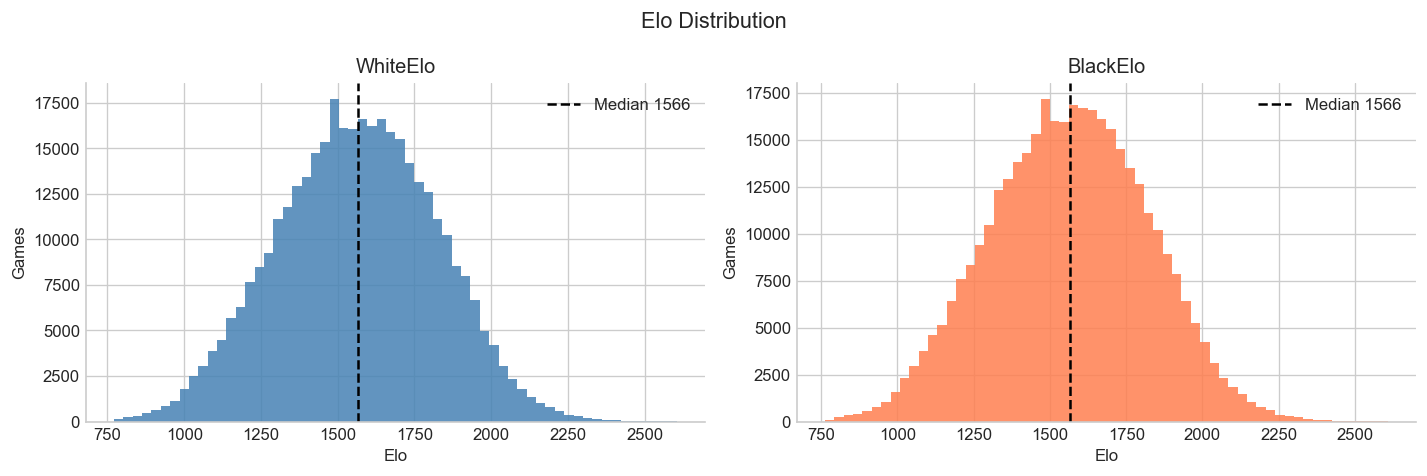

In [3]:
def load_pgn_zst(path, max_games):
    records = []
    with open(path, 'rb') as fh:
        dctx   = zstd.ZstdDecompressor()
        stream = io.TextIOWrapper(dctx.stream_reader(fh), encoding='utf-8', errors='replace')
        headers, moves_lines, in_moves = {}, [], False
        for line in stream:
            line = line.strip()
            if line.startswith('['):
                in_moves = False
                m = re.match(r'\[(\w+)\s+"(.*)"\]', line)
                if m: headers[m.group(1)] = m.group(2)
            elif line == '':
                if headers and moves_lines:
                    headers['Moves'] = ' '.join(moves_lines)
                    records.append(headers)
                    headers, moves_lines = {}, []
                    if len(records) >= max_games: break
                elif headers:
                    in_moves = True
            else:
                if in_moves or headers: moves_lines.append(line)
        if headers and moves_lines and len(records) < max_games:
            headers['Moves'] = ' '.join(moves_lines)
            records.append(headers)
    return pd.DataFrame(records)


t0     = time.time()
df_raw = load_pgn_zst(DATA_PATH, MAX_GAMES)
print(f'Loaded {len(df_raw):,} games in {time.time()-t0:.1f}s')

for col in ['WhiteElo', 'BlackElo']:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
df_raw.dropna(subset=['WhiteElo', 'BlackElo', 'Moves'], inplace=True)
df_raw[['WhiteElo', 'BlackElo']] = df_raw[['WhiteElo', 'BlackElo']].astype(int)

if 'Termination' in df_raw.columns:
    before = len(df_raw)
    df_raw = df_raw[~df_raw['Termination'].isin(EXCLUDE_TERMS)].reset_index(drop=True)
    print(f'Removed {before - len(df_raw):,} games by termination type')

tc_pattern = re.compile(r'^(\d+)\+(\d+)')
def parse_tc(tc_str):
    m = tc_pattern.match(str(tc_str))
    return (int(m.group(1)), int(m.group(2))) if m else (np.nan, np.nan)

df_raw[['tc_base', 'tc_inc']] = df_raw['TimeControl'].apply(lambda x: pd.Series(parse_tc(x)))
df_raw.dropna(subset=['tc_base'], inplace=True)
df_raw['tc_base'] = df_raw['tc_base'].astype(int)
df_raw['tc_inc']  = df_raw['tc_inc'].astype(int)

before = len(df_raw)
if TIME_CONTROL: df_raw = df_raw[df_raw['TimeControl'].astype(str) == TIME_CONTROL]
if TC_BASE_MIN:  df_raw = df_raw[df_raw['tc_base'] >= TC_BASE_MIN]
if TC_BASE_MAX:  df_raw = df_raw[df_raw['tc_base'] <= TC_BASE_MAX]
df_raw = df_raw.reset_index(drop=True)

print(f'Kept {len(df_raw):,} games after filters (removed {before - len(df_raw):,})')
print(f'Elo range — White: {df_raw.WhiteElo.min()}–{df_raw.WhiteElo.max()},  '
      f'Black: {df_raw.BlackElo.min()}–{df_raw.BlackElo.max()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, color in zip(axes, ['WhiteElo', 'BlackElo'], ['steelblue', 'coral']):
    ax.hist(df_raw[col], bins=60, color=color, edgecolor='none', alpha=0.85)
    ax.axvline(df_raw[col].median(), color='black', lw=1.5, ls='--',
               label=f'Median {df_raw[col].median():.0f}')
    ax.set_xlabel('Elo'); ax.set_ylabel('Games')
    ax.set_title(col); ax.legend()
plt.suptitle('Elo Distribution', fontsize=13)
plt.tight_layout(); plt.show()

## Feature Extraction

In [4]:
CLK_RE = re.compile(r'\[%clk\s+(\d+):(\d+):(\d+(?:\.\d+)?)\]')

def extract_clocks(pgn_str):
    return [int(h)*3600 + int(m)*60 + float(s)
            for h, m, s in CLK_RE.findall(pgn_str)]

def clock_features(pgn_str, tc_base):
    clocks = extract_clocks(pgn_str)
    empty  = {k: np.nan for k in [
        'w_avg_time_norm', 'w_std_time_norm', 'w_max_time_norm', 'w_time_pressure', 'w_opening_pace',
        'b_avg_time_norm', 'b_std_time_norm', 'b_max_time_norm', 'b_time_pressure', 'b_opening_pace']}
    if len(clocks) < 4 or tc_base <= 0: return empty
    white_clocks = clocks[0::2]
    black_clocks = clocks[1::2]
    def time_spent(cl):
        return [max(0., cl[i] - cl[i+1]) for i in range(len(cl)-1)] if len(cl) > 1 else [0.]
    def player_stats(spent, remaining, tc):
        s = np.array(spent); r = np.array(remaining)
        return {
            'avg_time_norm': float(s.mean() / tc),
            'std_time_norm': float(s.std()  / tc) if len(s) > 1 else 0.,
            'max_time_norm': float(s.max()  / tc),
            'time_pressure': int(np.sum(r[1:] < 30)) if len(r) > 1 else 0,
            'opening_pace':  float(np.mean(spent[:5]) / tc) if len(spent) >= 5 else float(s.mean() / tc),
        }
    ws = player_stats(time_spent(white_clocks), white_clocks, tc_base)
    bs = player_stats(time_spent(black_clocks), black_clocks, tc_base)
    return {f'w_{k}': v for k, v in ws.items()} | {f'b_{k}': v for k, v in bs.items()}


cache_key   = f'{len(df_raw)}_{MAX_GAMES}'
board_cache = CACHE_DIR / f'board_{cache_key}.pkl'
clock_cache = CACHE_DIR / f'clock_{cache_key}.pkl'

if board_cache.exists():
    board_feats = pd.read_pickle(board_cache)
    print(f'Board features loaded from cache  ({board_feats.shape[1]} cols)')
else:
    print('Extracting board features (runs once then caches)...')
    t0 = time.time()
    board_feats = cff.extract_features_dataframe(df_raw, n_jobs=-1)
    board_feats.to_pickle(board_cache)
    print(f'  Done in {time.time()-t0:.0f}s — {board_feats.shape[1]} cols')

if clock_cache.exists():
    clock_feats = pd.read_pickle(clock_cache)
    print(f'Clock features loaded from cache  ({clock_feats.shape[1]} cols)')
else:
    print('Extracting clock features...')
    t0 = time.time()
    rows = Parallel(n_jobs=-1)(
        delayed(clock_features)(moves, tc)
        for moves, tc in zip(df_raw['Moves'].tolist(), df_raw['tc_base'].tolist()))
    clock_feats = pd.DataFrame(rows, index=df_raw.index)
    clock_feats.to_pickle(clock_cache)
    print(f'  Done in {time.time()-t0:.0f}s — {clock_feats.shape[1]} cols')

for side in ['castle_side_white', 'castle_side_black']:
    if side in board_feats.columns:
        dummies     = pd.get_dummies(board_feats[side], prefix=side)
        board_feats = pd.concat([board_feats.drop(columns=[side]), dummies], axis=1)

df = pd.concat([df_raw, board_feats, clock_feats], axis=1)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f'Full feature matrix: {df.shape}')

Board features loaded from cache  (35 cols)
Clock features loaded from cache  (10 cols)
Full feature matrix: (372502, 69)


## Move Tokenisation

In [5]:
move_to_id = {'<PAD>': 0, '<UNK>': 1}

def add_move(move):
    if move not in move_to_id:
        move_to_id[move] = len(move_to_id)

def encode_move(move):
    return move_to_id.get(move, 1)

def vocab_size():
    return len(move_to_id)


MOVE_RE = re.compile(r'(?:\d+\.+\s*)?([KQRBN]?[a-h]?[1-8]?x?[a-h][1-8](?:=[QRBN])?[+#]?|O-O-O[+#]?|O-O[+#]?)')
EVAL_RE = re.compile(r'\[%eval\s+([^\]]+)\]')

def parse_moves(pgn_str):
    moves  = MOVE_RE.findall(pgn_str)
    clocks = extract_clocks(pgn_str)
    evals  = []
    for e in EVAL_RE.findall(pgn_str):
        try:    evals.append(100. if '#' in e else float(e))
        except: evals.append(0.)
    return moves, clocks, evals


parsed = df['Moves'].apply(parse_moves)
df['clean_moves']  = parsed.apply(lambda x: x[0])
df['clean_clocks'] = parsed.apply(lambda x: x[1])
df['clean_evals']  = parsed.apply(lambda x: x[2])
df['n_moves']      = df['clean_moves'].apply(len)

before = len(df)
df = df[df['n_moves'] >= MIN_PLIES].reset_index(drop=True)
print(f'Dropped {before - len(df):,} games shorter than {MIN_PLIES} plies')

for move_list in df['clean_moves']:
    for move in move_list:
        add_move(move)

print(f'Vocabulary size : {vocab_size():,}')
print(f'Games ready     : {len(df):,}')

Dropped 6,099 games shorter than 12 plies
Vocabulary size : 9,682
Games ready     : 366,403


## Soft Distribution Targets

1600 Elo dist: peak at 1550,  recovered = 1600


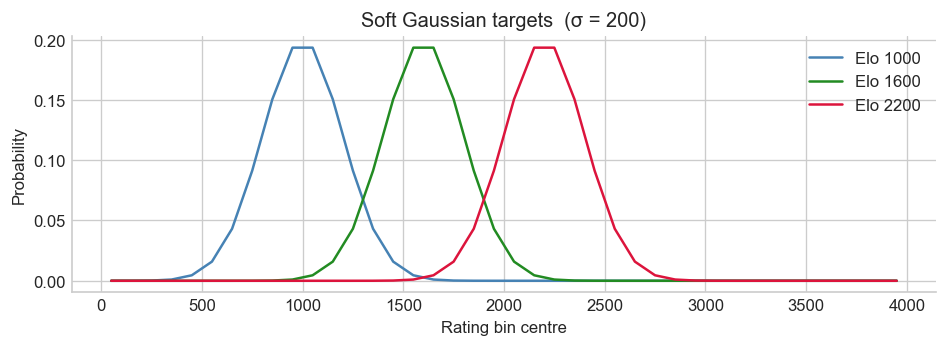

In [6]:
def make_elo_dist(elo, sigma=ELO_SIGMA):
    probs = np.exp(-0.5 * ((BIN_CENTERS - elo) / sigma) ** 2)
    return (probs / probs.sum()).astype(np.float32)

def dist_to_elo(dist):
    return float(np.dot(dist, BIN_CENTERS))

test_dist = make_elo_dist(1600)
print(f'1600 Elo dist: peak at {BIN_CENTERS[test_dist.argmax()]:.0f},  '
      f'recovered = {dist_to_elo(test_dist):.0f}')

fig, ax = plt.subplots(figsize=(8, 3))
for elo, color in [(1000, 'steelblue'), (1600, 'forestgreen'), (2200, 'crimson')]:
    ax.plot(BIN_CENTERS, make_elo_dist(elo), label=f'Elo {elo}', color=color)
ax.set_xlabel('Rating bin centre'); ax.set_ylabel('Probability')
ax.set_title('Soft Gaussian targets  (σ = 200)')
ax.legend()
plt.tight_layout(); plt.show()

## Feature Selection, Train/Val/Test Split & Scaling

In [7]:
excluded_cols  = {'WhiteElo', 'BlackElo', 'n_moves'}
all_numeric    = [c for c in df.select_dtypes(include=[np.number]).columns
                  if c not in excluded_cols]

active_prefixes = []
for group_name, is_active in FEATURE_GROUPS.items():
    if is_active:
        active_prefixes.extend(GROUP_PREFIXES.get(group_name, []))

static_cols = [c for c in all_numeric
               if any(c.startswith(p) for p in active_prefixes)]
num_static  = len(static_cols)
print(f'Static feature columns selected: {num_static}')

avg_elo    = (df['WhiteElo'] + df['BlackElo']) / 2
elo_strata = pd.cut(avg_elo, bins=ELO_BINS, labels=False).fillna(0).astype(int)

idx_train, idx_temp = train_test_split(
    df.index, test_size=VAL_FRAC + TEST_FRAC,
    stratify=elo_strata, random_state=RANDOM_STATE)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC),
    stratify=elo_strata.loc[idx_temp], random_state=RANDOM_STATE)

print(f'Split — train: {len(idx_train):,}  val: {len(idx_val):,}  test: {len(idx_test):,}')

# cast to float64 first — tc_base, tc_inc and count columns are int,
# and pandas 2.0 raises LossySetitemError if we write floats into int columns
df[static_cols] = df[static_cols].astype(np.float64)

scaler = StandardScaler()
scaler.fit(df.loc[idx_train, static_cols].fillna(0))
df[static_cols] = scaler.transform(df[static_cols].fillna(0))
print('Scaling done (StandardScaler fit on train only)')

Static feature columns selected: 45
Split — train: 293,122  val: 36,640  test: 36,641
Scaling done (StandardScaler fit on train only)


## Sequence Autoencoder

Same AE as v4: BiLSTM encoder → 32-d bottleneck. Loaded from cache if available, otherwise trained.
The AE embeddings give the residual MLP access to compressed sequence information as extra static features.

In [8]:
ae_emb_cache = CACHE_DIR / f'ae_embeddings_{len(df)}_{AE_LATENT_DIM}.npy'


def build_encoder(n_vocab, embed_dim, hidden_dim, latent_dim, dropout=0.2):
    embed = nn.Embedding(n_vocab, embed_dim, padding_idx=0)
    lstm  = nn.LSTM(embed_dim, hidden_dim, num_layers=2,
                    batch_first=True, bidirectional=True, dropout=dropout)
    proj  = nn.Linear(hidden_dim * 2, latent_dim)

    class Encoder(nn.Module):
        def __init__(self):
            super().__init__()
            self.embed = embed; self.lstm = lstm; self.proj = proj
        def forward(self, x, mask=None):
            e      = self.embed(x)
            out, _ = self.lstm(e)
            if mask is not None:
                m   = mask.unsqueeze(-1).float()
                ctx = (out * m).sum(1) / m.sum(1).clamp(min=1)
            else:
                ctx = out.mean(1)
            return torch.tanh(self.proj(ctx))
    return Encoder()


def build_decoder(n_vocab, embed_dim, hidden_dim, latent_dim):
    latent2h = nn.Linear(latent_dim, hidden_dim)
    embed    = nn.Embedding(n_vocab, embed_dim, padding_idx=0)
    lstm     = nn.LSTM(embed_dim + latent_dim, hidden_dim, num_layers=1, batch_first=True)
    out_proj = nn.Linear(hidden_dim, n_vocab)

    class Decoder(nn.Module):
        def __init__(self):
            super().__init__()
            self.latent2h = latent2h; self.embed = embed
            self.lstm = lstm; self.out_proj = out_proj
        def forward(self, z, target_ids):
            e      = self.embed(target_ids)
            z_exp  = z.unsqueeze(1).expand(-1, e.size(1), -1)
            x      = torch.cat([e, z_exp], dim=-1)
            h0     = torch.tanh(self.latent2h(z)).unsqueeze(0)
            c0     = torch.zeros_like(h0)
            out, _ = self.lstm(x, (h0, c0))
            return self.out_proj(out)
    return Decoder()


class MoveSeqDataset(Dataset):
    def __init__(self, move_lists, max_seq=None):
        self.sequences = []
        for moves in move_lists:
            ids = [encode_move(m) for m in moves[:max_seq]]
            self.sequences.append(torch.tensor(ids, dtype=torch.long))
    def __len__(self):         return len(self.sequences)
    def __getitem__(self, i):  return self.sequences[i]


def pad_seqs(batch):
    padded = pad_sequence(batch, batch_first=True, padding_value=0)
    return padded, (padded != 0)


if ae_emb_cache.exists():
    ae_embeddings = np.load(ae_emb_cache)
    print(f'AE embeddings loaded from cache: {ae_embeddings.shape}')
else:
    print('Training sequence autoencoder...')
    encoder = build_encoder(vocab_size(), 64, 128, AE_LATENT_DIM).to(device)
    decoder = build_decoder(vocab_size(), 64, 128, AE_LATENT_DIM).to(device)
    ae_params = list(encoder.parameters()) + list(decoder.parameters())
    ae_opt    = torch.optim.Adam(ae_params, lr=1e-3)
    ae_loss   = nn.CrossEntropyLoss(ignore_index=0)

    sample_moves = df['clean_moves'].sample(frac=AE_TRAIN_FRAC, random_state=RANDOM_STATE).tolist()
    train_seqs   = MoveSeqDataset(sample_moves, max_seq=AE_MAX_SEQ)
    train_loader_ae = DataLoader(train_seqs, batch_size=AE_BATCH_SIZE,
                                  shuffle=True, collate_fn=pad_seqs, num_workers=0)

    for epoch in range(AE_EPOCHS):
        encoder.train(); decoder.train()
        total_loss, n_batches = 0., 0
        for ids, mask in train_loader_ae:
            ids, mask = ids.to(device), mask.to(device)
            z      = encoder(ids, mask)
            logits = decoder(z, ids)
            loss   = ae_loss(logits[:, :-1].reshape(-1, vocab_size()),
                             ids[:, 1:].reshape(-1))
            ae_opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(ae_params, 1.)
            ae_opt.step()
            total_loss += loss.item(); n_batches += 1
        print(f'  AE epoch {epoch+1}/{AE_EPOCHS}  loss={total_loss/n_batches:.4f}')

    torch.save(encoder.state_dict(), AE_MODEL_PATH)

    encoder.eval()
    all_seqs   = MoveSeqDataset(df['clean_moves'].tolist(), max_seq=AE_MAX_SEQ)
    enc_loader = DataLoader(all_seqs, batch_size=1024, shuffle=False,
                             collate_fn=pad_seqs, num_workers=0)
    all_embeddings = []
    with torch.no_grad():
        for ids, mask in enc_loader:
            z = encoder(ids.to(device), mask.to(device))
            all_embeddings.append(z.cpu().numpy())
    ae_embeddings = np.vstack(all_embeddings)
    np.save(ae_emb_cache, ae_embeddings)
    print(f'AE embeddings saved: {ae_embeddings.shape}')

ae_cols = [f'ae_{i}' for i in range(AE_LATENT_DIM)]
df_ae   = pd.DataFrame(ae_embeddings, columns=ae_cols, index=df.index)
print(f'AE embeddings ready — {AE_LATENT_DIM} dims per game')

AE embeddings loaded from cache: (366403, 32)
AE embeddings ready — 32 dims per game


## Dataset & DataLoaders

In [9]:
class ChessDataset(Dataset):
    """Static-only dataset — combines static features with AE embeddings."""
    def __init__(self, df_subset, static_cols, ae_df, use_dist=True):
        self.items  = []
        static_vals = df_subset[static_cols].fillna(0).values.astype(np.float32)
        ae_vals     = ae_df.loc[df_subset.index].values.astype(np.float32)

        for i, (_, row) in enumerate(df_subset.iterrows()):
            combined  = np.concatenate([static_vals[i], ae_vals[i]]).astype(np.float32)
            white_elo = float(row['WhiteElo'])
            black_elo = float(row['BlackElo'])
            if use_dist:
                white_target = torch.tensor(make_elo_dist(white_elo), dtype=torch.float32)
                black_target = torch.tensor(make_elo_dist(black_elo), dtype=torch.float32)
            else:
                white_target = torch.tensor([white_elo], dtype=torch.float32)
                black_target = torch.tensor([black_elo], dtype=torch.float32)
            # placeholder tensors so the training loop doesn't need special-casing
            self.items.append({
                'moves':     torch.zeros(1, dtype=torch.long),
                'clocks':    torch.zeros(1),
                'turns':     torch.zeros(1),
                'static':    torch.tensor(combined, dtype=torch.float32),
                'white_tgt': white_target,
                'black_tgt': black_target,
                'raw_elo':   torch.tensor([white_elo, black_elo], dtype=torch.float32),
            })

    def __len__(self):         return len(self.items)
    def __getitem__(self, i):  return self.items[i]


def collate_games(batch):
    return {
        'moves':     torch.stack([b['moves']     for b in batch]),
        'clocks':    torch.stack([b['clocks']    for b in batch]),
        'turns':     torch.stack([b['turns']     for b in batch]),
        'mask':      torch.ones(len(batch), 1),
        'static':    torch.stack([b['static']    for b in batch]),
        'white_tgt': torch.stack([b['white_tgt'] for b in batch]),
        'black_tgt': torch.stack([b['black_tgt'] for b in batch]),
        'raw_elo':   torch.stack([b['raw_elo']   for b in batch]),
    }


total_static_dim = num_static + AE_LATENT_DIM

print('Building datasets...')
t0 = time.time()
train_ds = ChessDataset(df.loc[idx_train], static_cols, df_ae, USE_DIST_TARGET)
val_ds   = ChessDataset(df.loc[idx_val],   static_cols, df_ae, USE_DIST_TARGET)
test_ds  = ChessDataset(df.loc[idx_test],  static_cols, df_ae, USE_DIST_TARGET)
print(f'  Built in {time.time()-t0:.0f}s   total static dim = {total_static_dim}')

train_elos     = (df.loc[idx_train, 'WhiteElo'] + df.loc[idx_train, 'BlackElo']) / 2
sample_weights = cff.compute_elo_sample_weights(train_elos, ELO_BINS)
sampler        = WeightedRandomSampler(
    torch.tensor(sample_weights, dtype=torch.float32),
    num_samples=len(train_ds), replacement=True)

loader_kwargs = dict(batch_size=BATCH_SIZE, collate_fn=collate_games,
                     pin_memory=(device.type=='cuda'), num_workers=NUM_WORKERS)
train_loader  = DataLoader(train_ds, sampler=sampler, **loader_kwargs)
val_loader    = DataLoader(val_ds,   shuffle=False,   **loader_kwargs)
test_loader   = DataLoader(test_ds,  shuffle=False,   **loader_kwargs)
print(f'Batches per epoch: {len(train_loader):,}')

Building datasets...
  Built in 89s   total static dim = 77
Batches per epoch: 2,291


## Model — Residual MLP

Each residual block: `LayerNorm → Linear → GELU → Dropout → Linear → LayerNorm` with a skip connection.
Pre-norm (LayerNorm before the non-linearity) is more stable than post-norm when stacking many blocks.

An input projection lifts the feature vector to `hidden_dim`, then N residual blocks process it, and
two output heads (White/Black) produce 40-bin softmax distributions.

In [10]:
class ResBlock(nn.Module):
    """Pre-norm residual block: x + Linear(GELU(Linear(LayerNorm(x))))"""
    def __init__(self, dim, dropout):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.fc1   = nn.Linear(dim, dim * 2)
        self.fc2   = nn.Linear(dim * 2, dim)
        self.norm2 = nn.LayerNorm(dim)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        # pre-norm: normalise before the transformation, add residual after
        h = self.fc2(self.drop(F.gelu(self.fc1(self.norm1(x)))))
        return self.norm2(x + h)


def build_residual_model(n_static, hidden_dim, n_blocks, dropout, n_bins):
    """
    Build the residual MLP Elo predictor.
    Input projection → N residual blocks → two output heads.
    No sequence processing — all information comes from static + AE features.
    """
    input_proj = nn.Sequential(
        nn.Linear(n_static, hidden_dim),
        nn.LayerNorm(hidden_dim),
        nn.GELU(),
        nn.Dropout(dropout),
    )
    blocks    = nn.ModuleList([ResBlock(hidden_dim, dropout) for _ in range(n_blocks)])
    white_head = nn.Linear(hidden_dim, n_bins)
    black_head = nn.Linear(hidden_dim, n_bins)

    class ResidualEloPredictor(nn.Module):
        def __init__(self):
            super().__init__()
            self.input_proj = input_proj
            self.blocks     = blocks
            self.white_head = white_head
            self.black_head = black_head
            self._init_weights()

        def _init_weights(self):
            for m in self.modules():
                if isinstance(m, nn.Linear):
                    nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                    if m.bias is not None: nn.init.zeros_(m.bias)

        def forward(self, moves, clocks, turns, mask, static_feats):
            # moves/clocks/turns/mask are ignored — this is a static model
            x = self.input_proj(static_feats)
            for block in self.blocks:
                x = block(x)
            white_probs = torch.softmax(self.white_head(x), dim=-1)
            black_probs = torch.softmax(self.black_head(x), dim=-1)
            dummy_attn  = torch.zeros(static_feats.size(0), 1, device=static_feats.device)
            return white_probs, black_probs, dummy_attn

        def game_embedding(self, moves, clocks, turns, mask, static_feats):
            x = self.input_proj(static_feats)
            for block in self.blocks:
                x = block(x)
            return x

        @staticmethod
        def probs_to_elo(probs):
            bins = torch.tensor(BIN_CENTERS, dtype=probs.dtype, device=probs.device)
            return (probs * bins).sum(dim=-1)

    return ResidualEloPredictor()


model = build_residual_model(
    n_static=total_static_dim, hidden_dim=HIDDEN_DIM,
    n_blocks=N_BLOCKS, dropout=DROPOUT, n_bins=N_BINS,
).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model built — {n_params:,} trainable parameters  |  hidden_dim={HIDDEN_DIM}  n_blocks={N_BLOCKS}')

Model built — 1,096,784 trainable parameters  |  hidden_dim=256  n_blocks=4


## Hyperparameter Optimisation (Optuna)

15 trials on a 50k-game subset, 3 training epochs each. Searches:
- `n_blocks`: residual depth {2, 4, 6, 8}
- `hidden_dim`: feature width {128, 256, 512}
- `dropout`: regularisation strength {0.1 … 0.4}

In [11]:
hpo_cache = CKPT_DIR / 'residual_hpo_best.pkl'

if hpo_cache.exists():
    import pickle
    best_params = pickle.loads(hpo_cache.read_bytes())
    print(f'HPO cache found — best params: {best_params}')
else:
    hpo_n   = min(HPO_GAMES, len(idx_train))
    hpo_idx = pd.Index(np.random.default_rng(RANDOM_STATE).choice(idx_train, size=hpo_n, replace=False))
    hpo_ds  = ChessDataset(df.loc[hpo_idx], static_cols, df_ae, USE_DIST_TARGET)
    hpo_ldr = DataLoader(hpo_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_games, num_workers=NUM_WORKERS)

    kl_loss = nn.KLDivLoss(reduction='batchmean')

    def hpo_objective(trial):
        n_blks   = trial.suggest_categorical('n_blocks',   [2, 4, 6, 8])
        hid_dim  = trial.suggest_categorical('hidden_dim', [128, 256, 512])
        dropout  = trial.suggest_float('dropout', 0.1, 0.4)

        m = build_residual_model(
            n_static=total_static_dim, hidden_dim=hid_dim,
            n_blocks=n_blks, dropout=dropout, n_bins=N_BINS,
        ).to(device)
        opt = torch.optim.AdamW(m.parameters(), lr=3e-4, weight_decay=1e-4)

        for _ in range(HPO_EPOCHS):
            m.train()
            for batch in hpo_ldr:
                moves  = batch['moves'].to(device)
                clocks = batch['clocks'].to(device)
                turns  = batch['turns'].to(device)
                mask   = batch['mask'].to(device)
                static = batch['static'].to(device)
                wp, bp, _ = m(moves, clocks, turns, mask, static)
                loss = (kl_loss(torch.log(wp.clamp(min=1e-9)), batch['white_tgt'].to(device)) +
                        kl_loss(torch.log(bp.clamp(min=1e-9)), batch['black_tgt'].to(device)))
                opt.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(m.parameters(), 1.)
                opt.step()

        m.eval()
        val_loss, n_val = 0., 0
        with torch.no_grad():
            for batch in val_loader:
                static = batch['static'].to(device)
                moves  = batch['moves'].to(device)
                clocks = batch['clocks'].to(device)
                turns  = batch['turns'].to(device)
                mask   = batch['mask'].to(device)
                wp, bp, _ = m(moves, clocks, turns, mask, static)
                val_loss += (kl_loss(torch.log(wp.clamp(min=1e-9)), batch['white_tgt'].to(device)) +
                             kl_loss(torch.log(bp.clamp(min=1e-9)), batch['black_tgt'].to(device))).item()
                n_val += 1
        del m
        return val_loss / max(n_val, 1)

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(hpo_objective, n_trials=HPO_TRIALS, show_progress_bar=True)

    best_params = study.best_params
    print(f'\nBest trial  val_loss={study.best_value:.4f}')
    print(f'Best params: {best_params}')

    import pickle
    hpo_cache.write_bytes(pickle.dumps(best_params))

N_BLOCKS   = best_params.get('n_blocks',   N_BLOCKS)
HIDDEN_DIM = best_params.get('hidden_dim', HIDDEN_DIM)
DROPOUT    = best_params.get('dropout',    DROPOUT)
print(f'\nFull training will use: n_blocks={N_BLOCKS}  hidden_dim={HIDDEN_DIM}  dropout={DROPOUT:.3f}')

Best trial: 12. Best value: 0.747337: 100%|██████████| 15/15 [08:33<00:00, 34.23s/it]


Best trial  val_loss=0.7473
Best params: {'n_blocks': 2, 'hidden_dim': 256, 'dropout': 0.11103653555313633}

Full training will use: n_blocks=2  hidden_dim=256  dropout=0.111


## Training

Epoch  1/10  train 0.9597  val 0.9980  MAE W:200 B:198  lr 2.93e-04  41.9s
Epoch  2/10  train 0.8258  val 0.9709  MAE W:196 B:192  lr 2.73e-04  37.6s
Epoch  3/10  train 0.7712  val 0.9572  MAE W:192 B:190  lr 2.41e-04  31.5s
Epoch  4/10  train 0.7361  val 0.9296  MAE W:191 B:189  lr 2.02e-04  31.1s
Epoch  5/10  train 0.7130  val 0.9215  MAE W:188 B:190  lr 1.57e-04  34.8s
Epoch  6/10  train 0.6928  val 0.9549  MAE W:192 B:195  lr 1.13e-04  33.1s
Epoch  7/10  train 0.6803  val 0.9036  MAE W:186 B:187  lr 7.37e-05  31.1s
Epoch  8/10  train 0.6673  val 0.9003  MAE W:187 B:185  lr 4.22e-05  31.2s
Epoch  9/10  train 0.6592  val 0.9007  MAE W:187 B:185  lr 2.20e-05  32.4s
Epoch 10/10  train 0.6591  val 0.8889  MAE W:185 B:184  lr 1.50e-05  30.8s


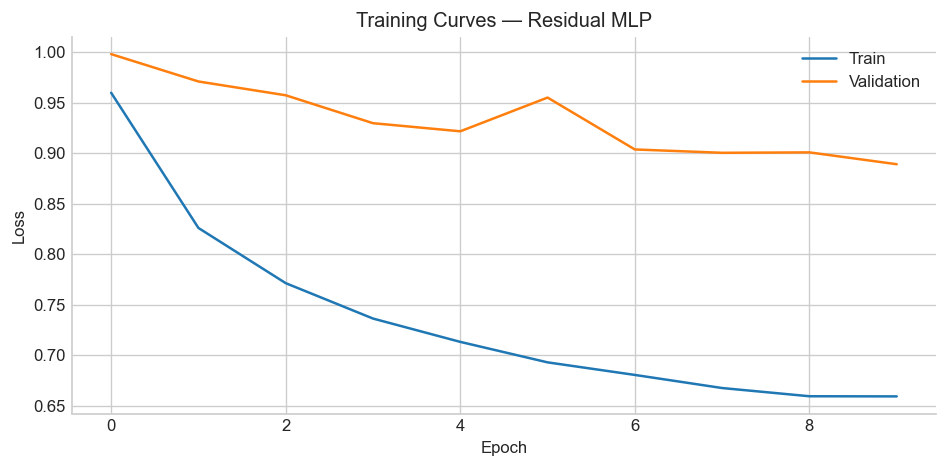

In [12]:
model_path = CKPT_DIR / f'residual_{MAX_GAMES:.0e}.pth'

if model_path.exists():
    print(f'Checkpoint found — skipping training. Delete to retrain: {model_path}')
else:
    model = build_residual_model(
        n_static=total_static_dim, hidden_dim=HIDDEN_DIM,
        n_blocks=N_BLOCKS, dropout=DROPOUT, n_bins=N_BINS,
    ).to(device)

    optimizer  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=LR*0.05)
    amp_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    kl_loss    = nn.KLDivLoss(reduction='batchmean')

    def compute_loss(white_pred, black_pred, batch):
        wl = torch.log(white_pred.clamp(min=1e-9))
        bl = torch.log(black_pred.clamp(min=1e-9))
        return (kl_loss(wl, batch['white_tgt'].to(device)) +
                kl_loss(bl, batch['black_tgt'].to(device)))

    def preds_to_elo(white_pred, black_pred):
        return (model.probs_to_elo(white_pred).detach().cpu().numpy(),
                model.probs_to_elo(black_pred).detach().cpu().numpy())

    train_losses, val_losses = [], []
    best_val, patience_ctr   = float('inf'), 0

    for epoch in range(NUM_EPOCHS):
        t_ep = time.time()
        model.train()
        running_loss, n_batches = 0., 0
        for batch in train_loader:
            moves  = batch['moves'].to(device, non_blocking=True)
            clocks = batch['clocks'].to(device, non_blocking=True)
            turns  = batch['turns'].to(device, non_blocking=True)
            mask   = batch['mask'].to(device, non_blocking=True)
            static = batch['static'].to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                wp, bp, _ = model(moves, clocks, turns, mask, static)
                loss = compute_loss(wp, bp, batch)
            optimizer.zero_grad(set_to_none=True)
            amp_scaler.scale(loss).backward()
            amp_scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.)
            amp_scaler.step(optimizer)
            amp_scaler.update()
            running_loss += loss.item(); n_batches += 1
        train_losses.append(running_loss / max(n_batches, 1))
        scheduler.step()

        model.eval()
        val_loss, val_batches = 0., 0
        white_preds, black_preds = [], []
        white_trues, black_trues = [], []
        with torch.no_grad():
            for batch in val_loader:
                moves  = batch['moves'].to(device)
                clocks = batch['clocks'].to(device)
                turns  = batch['turns'].to(device)
                mask   = batch['mask'].to(device)
                static = batch['static'].to(device)
                with torch.cuda.amp.autocast(enabled=USE_AMP):
                    wp, bp, _ = model(moves, clocks, turns, mask, static)
                    loss = compute_loss(wp, bp, batch)
                val_loss += loss.item(); val_batches += 1
                ep, ep2 = preds_to_elo(wp, bp)
                white_preds.extend(ep); black_preds.extend(ep2)
                white_trues.extend(batch['raw_elo'][:, 0].numpy())
                black_trues.extend(batch['raw_elo'][:, 1].numpy())

        val_loss /= max(val_batches, 1)
        val_losses.append(val_loss)
        w_mae = mean_absolute_error(white_trues, white_preds)
        b_mae = mean_absolute_error(black_trues, black_preds)
        print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS}  '
              f'train {train_losses[-1]:.4f}  val {val_loss:.4f}  '
              f'MAE W:{w_mae:.0f} B:{b_mae:.0f}  '
              f'lr {optimizer.param_groups[0]["lr"]:.2e}  {time.time()-t_ep:.1f}s')

        if val_loss < best_val * (1 - 1e-3):
            best_val, patience_ctr = val_loss, 0
            torch.save({
                'model_state': model.state_dict(),
                'move_to_id':  move_to_id,
                'static_cols': static_cols,
                'scaler_mean': scaler.mean_.tolist(),
                'scaler_std':  scaler.scale_.tolist(),
                'n_blocks':    N_BLOCKS,
                'hidden_dim':  HIDDEN_DIM,
                'dropout':     DROPOUT,
                'n_bins':      N_BINS,
                'n_static':    total_static_dim,
                'ae_latent':   AE_LATENT_DIM,
            }, model_path)
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'Early stopping at epoch {epoch+1}')
                break

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(train_losses, label='Train', lw=1.5)
    ax.plot(val_losses,   label='Validation', lw=1.5)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title('Training Curves — Residual MLP')
    ax.legend()
    plt.tight_layout(); plt.show()

## Evaluation

In [13]:
checkpoint = torch.load(model_path, map_location=device, weights_only=False)
model = build_residual_model(
    n_static=total_static_dim, hidden_dim=checkpoint['hidden_dim'],
    n_blocks=checkpoint['n_blocks'], dropout=checkpoint['dropout'],
    n_bins=checkpoint['n_bins'],
).to(device)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f'Loaded checkpoint: {model_path}')

def preds_to_elo(white_pred, black_pred):
    return (model.probs_to_elo(white_pred).detach().cpu().numpy(),
            model.probs_to_elo(black_pred).detach().cpu().numpy())


white_preds, black_preds = [], []
white_trues, black_trues = [], []

with torch.no_grad():
    for batch in test_loader:
        moves  = batch['moves'].to(device)
        clocks = batch['clocks'].to(device)
        turns  = batch['turns'].to(device)
        mask   = batch['mask'].to(device)
        static = batch['static'].to(device)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            wp, bp, _ = model(moves, clocks, turns, mask, static)
        ep, ep2 = preds_to_elo(wp, bp)
        white_preds.extend(ep); black_preds.extend(ep2)
        white_trues.extend(batch['raw_elo'][:, 0].numpy())
        black_trues.extend(batch['raw_elo'][:, 1].numpy())

white_preds = np.array(white_preds); black_preds = np.array(black_preds)
white_trues = np.array(white_trues); black_trues = np.array(black_trues)
all_errors  = np.concatenate([np.abs(white_preds - white_trues),
                               np.abs(black_preds - black_trues)])
w_mae = mean_absolute_error(white_trues, white_preds)
b_mae = mean_absolute_error(black_trues, black_preds)

print(f'MAE    — White: {w_mae:.1f}  Black: {b_mae:.1f}  Combined: {(w_mae+b_mae)/2:.1f}')
print(f'Median — White: {median_absolute_error(white_trues, white_preds):.1f}  '
      f'Black: {median_absolute_error(black_trues, black_preds):.1f}')
print(f'Within 100 Elo: {np.mean(all_errors < 100)*100:.1f}%')
print(f'Within 200 Elo: {np.mean(all_errors < 200)*100:.1f}%')
print(f'Within 300 Elo: {np.mean(all_errors < 300)*100:.1f}%')

Loaded checkpoint: checkpoints\residual_3e+06.pth
MAE    — White: 186.1  Black: 184.6  Combined: 185.3
Median — White: 153.2  Black: 152.7
Within 100 Elo: 34.3%
Within 200 Elo: 61.9%
Within 300 Elo: 80.6%


In [14]:
# ── Comparison vs v4 baseline ─────────────────────────────────────────────────
V4_BASELINE_MAE = 200.0   # update with actual v4 test MAE
this_mae = (w_mae + b_mae) / 2

print('=' * 50)
print('  Architecture Comparison')
print('=' * 50)
print(f'  v4 (BiLSTM + AE)       combined MAE ≈ {V4_BASELINE_MAE:.1f}')
print(f'  Residual MLP (this)    combined MAE  = {this_mae:.1f}')
delta = this_mae - V4_BASELINE_MAE
direction = 'better' if delta < 0 else 'worse'
print(f'  Δ = {delta:+.1f} Elo  ({direction} than baseline)')
print('=' * 50)

  Architecture Comparison
  v4 (BiLSTM + AE)       combined MAE ≈ 200.0
  Residual MLP (this)    combined MAE  = 185.3
  Δ = -14.7 Elo  (better than baseline)


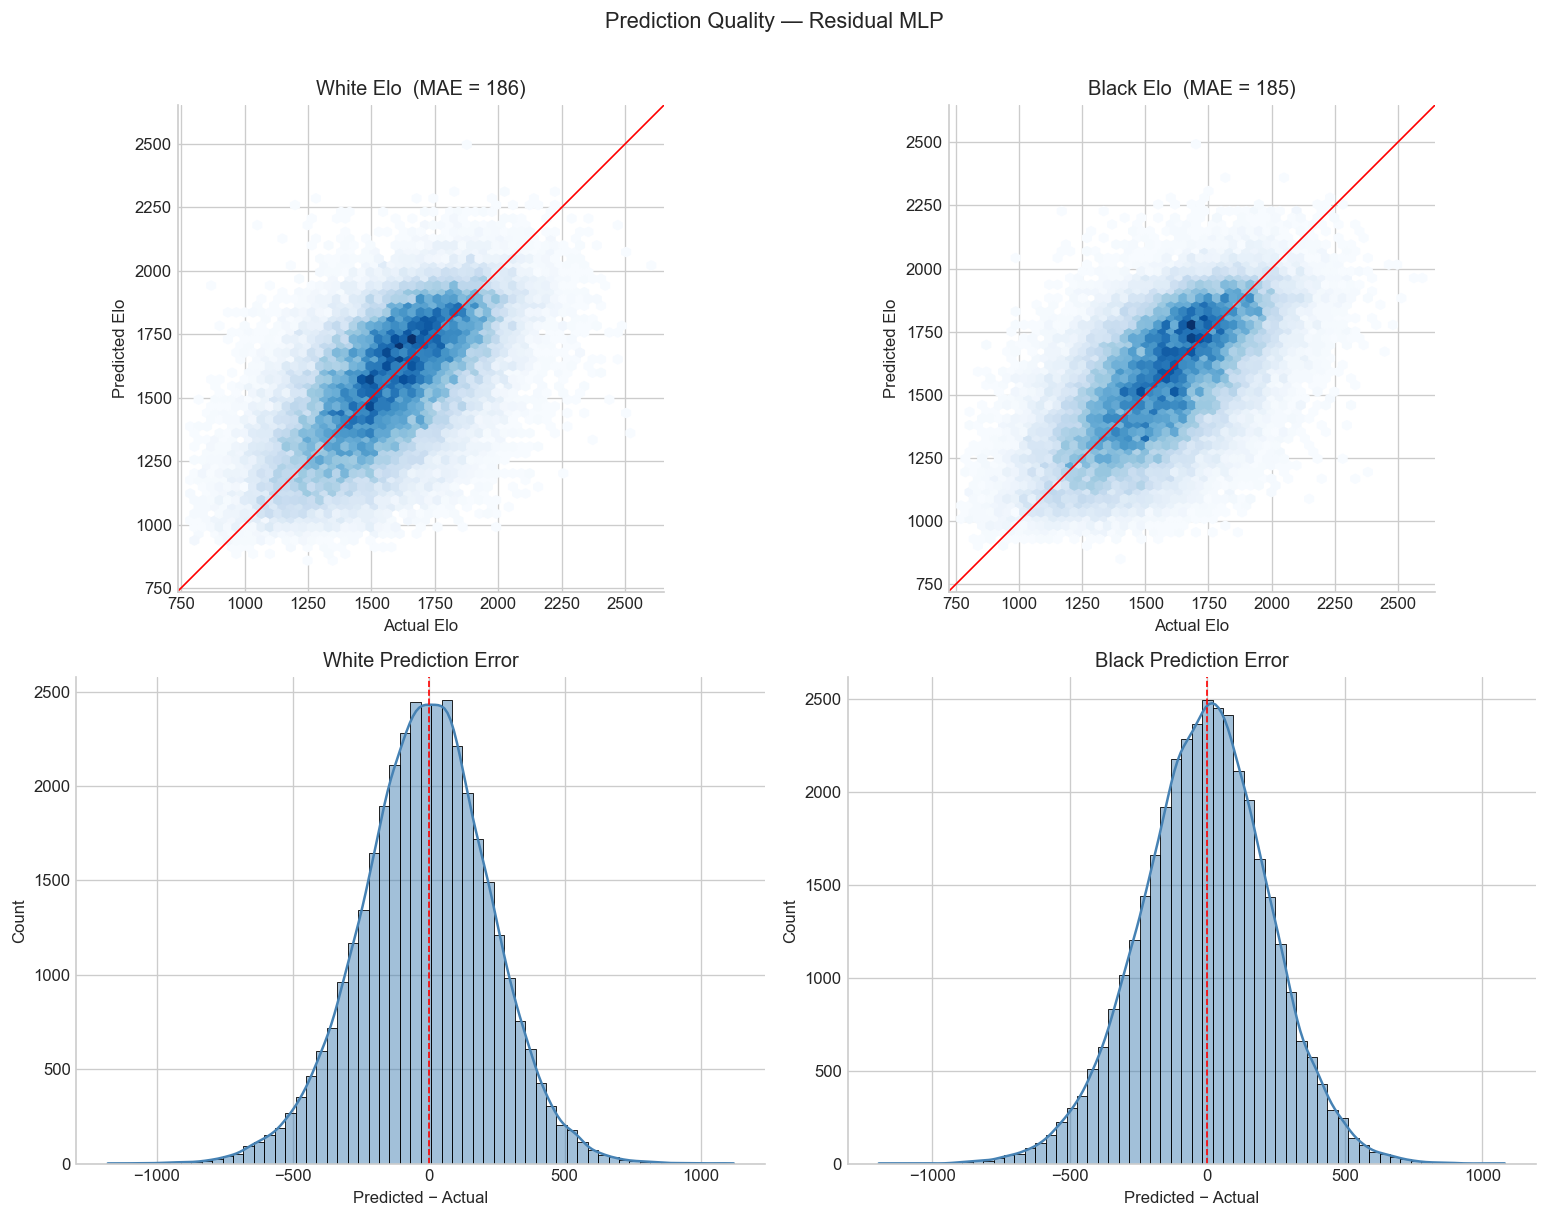

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, preds, trues, label in [
    (axes[0, 0], white_preds, white_trues, 'White Elo'),
    (axes[0, 1], black_preds, black_trues, 'Black Elo')]:
    lo = min(trues.min(), preds.min()) - 50
    hi = max(trues.max(), preds.max()) + 50
    ax.hexbin(trues, preds, gridsize=55, cmap='Blues', mincnt=1)
    ax.plot([lo, hi], [lo, hi], 'r-', lw=1)
    ax.set_xlabel('Actual Elo'); ax.set_ylabel('Predicted Elo')
    ax.set_title(f'{label}  (MAE = {mean_absolute_error(trues, preds):.0f})')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')
for ax, preds, trues, label in [
    (axes[1, 0], white_preds, white_trues, 'White Prediction Error'),
    (axes[1, 1], black_preds, black_trues, 'Black Prediction Error')]:
    sns.histplot(preds - trues, bins=60, kde=True, ax=ax, color='steelblue')
    ax.axvline(0, color='red', lw=1, ls='--')
    ax.set_xlabel('Predicted − Actual'); ax.set_title(label)
plt.suptitle('Prediction Quality — Residual MLP', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

MAE by Elo bracket:
------------------------------------------
           (0, 1000]  MAE =   278  n = 874
        (1000, 1200]  MAE =   199  n = 5,166
        (1200, 1400]  MAE =   183  n = 13,476
        (1400, 1600]  MAE =   176  n = 20,505
        (1600, 1800]  MAE =   169  n = 19,467
        (1800, 2000]  MAE =   189  n = 10,752
        (2000, 2200]  MAE =   276  n = 2,639
        (2200, 2500]  MAE =   423  n = 396
        (2500, 4000]  MAE =   733  n = 7


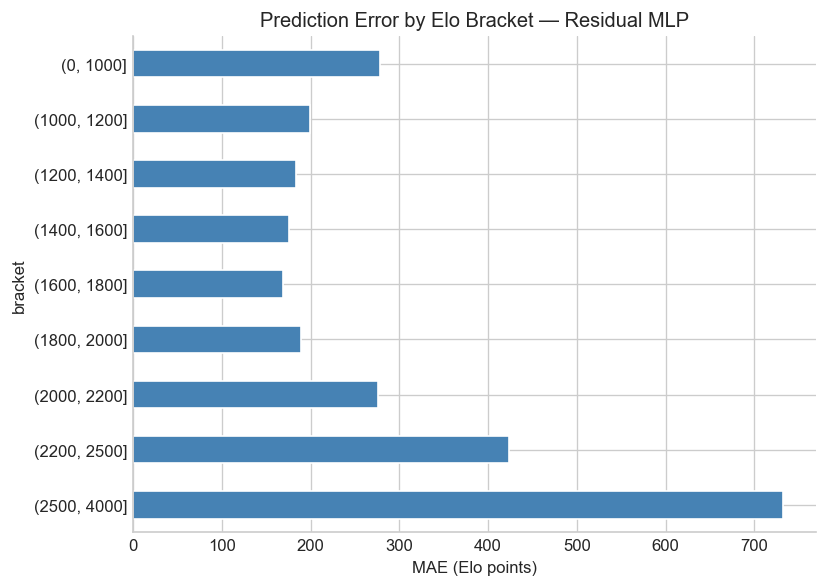

In [16]:
all_trues  = np.concatenate([white_trues, black_trues])
all_preds  = np.concatenate([white_preds, black_preds])
brackets   = pd.cut(all_trues, bins=ELO_BINS, right=True)
bracket_df = pd.DataFrame({'true': all_trues, 'pred': all_preds, 'bracket': brackets})
bracket_mae = bracket_df.groupby('bracket', observed=True).apply(
    lambda g: mean_absolute_error(g['true'], g['pred']), include_groups=False).sort_index()
bracket_n = bracket_df.groupby('bracket', observed=True).size().sort_index()

print('MAE by Elo bracket:')
print('-' * 42)
for bracket, mae in bracket_mae.items():
    print(f'  {str(bracket):>18s}  MAE = {mae:5.0f}  n = {bracket_n[bracket]:,}')

fig, ax = plt.subplots(figsize=(7, 5))
bracket_mae.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('MAE (Elo points)')
ax.set_title('Prediction Error by Elo Bracket — Residual MLP')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## Predicted Rating Distributions

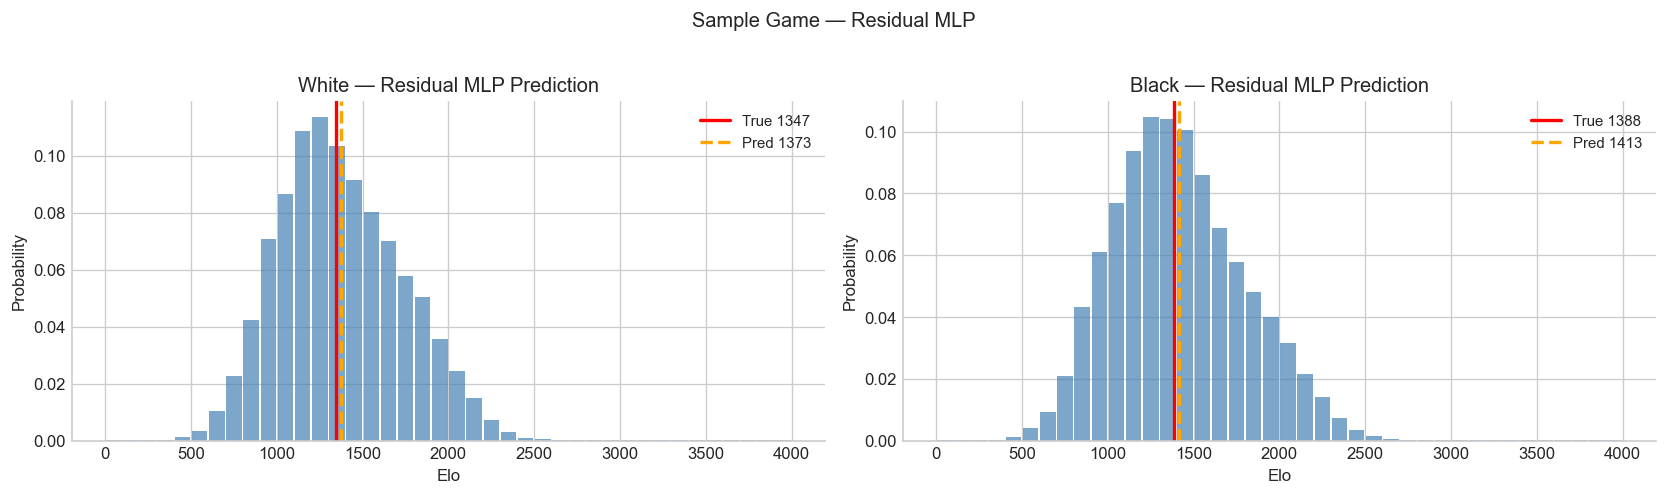

In [17]:
test_df    = df.loc[idx_test].reset_index(drop=True)
candidates = test_df[test_df['n_moves'].between(30, 50)]
if candidates.empty: candidates = test_df
game_idx = candidates.index[0]
sample   = test_ds[game_idx]

with torch.no_grad():
    static_t = sample['static'].unsqueeze(0).to(device)
    dummy_m  = sample['moves'].unsqueeze(0).to(device)
    dummy_c  = sample['clocks'].unsqueeze(0).to(device)
    dummy_t  = sample['turns'].unsqueeze(0).to(device)
    dummy_mk = torch.ones(1, 1).to(device)
    wp, bp, _ = model(dummy_m, dummy_c, dummy_t, dummy_mk, static_t)

white_dist = wp.cpu().numpy().squeeze()
black_dist = bp.cpu().numpy().squeeze()
white_true = test_df.iloc[game_idx]['WhiteElo']
black_true = test_df.iloc[game_idx]['BlackElo']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, dist, true_elo, label in [
    (axes[0], white_dist, white_true, 'White'),
    (axes[1], black_dist, black_true, 'Black')]:
    pred_elo = dist_to_elo(dist)
    ax.bar(BIN_CENTERS, dist, width=90, color='steelblue', alpha=0.7)
    ax.axvline(true_elo,  color='red',    lw=2, label=f'True {true_elo}')
    ax.axvline(pred_elo,  color='orange', lw=2, ls='--', label=f'Pred {pred_elo:.0f}')
    ax.set_xlabel('Elo'); ax.set_ylabel('Probability')
    ax.set_title(f'{label} — Residual MLP Prediction')
    ax.legend(fontsize=9)
plt.suptitle('Sample Game — Residual MLP', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

## Latent Space — t-SNE & PCA

C:\Users\EliasBenSlama\AppData\Local\Temp\ipykernel_32364\2214741828.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_d     = plt.cm.get_cmap('viridis', len(labels_vis))


Running t-SNE on 3000 vectors...


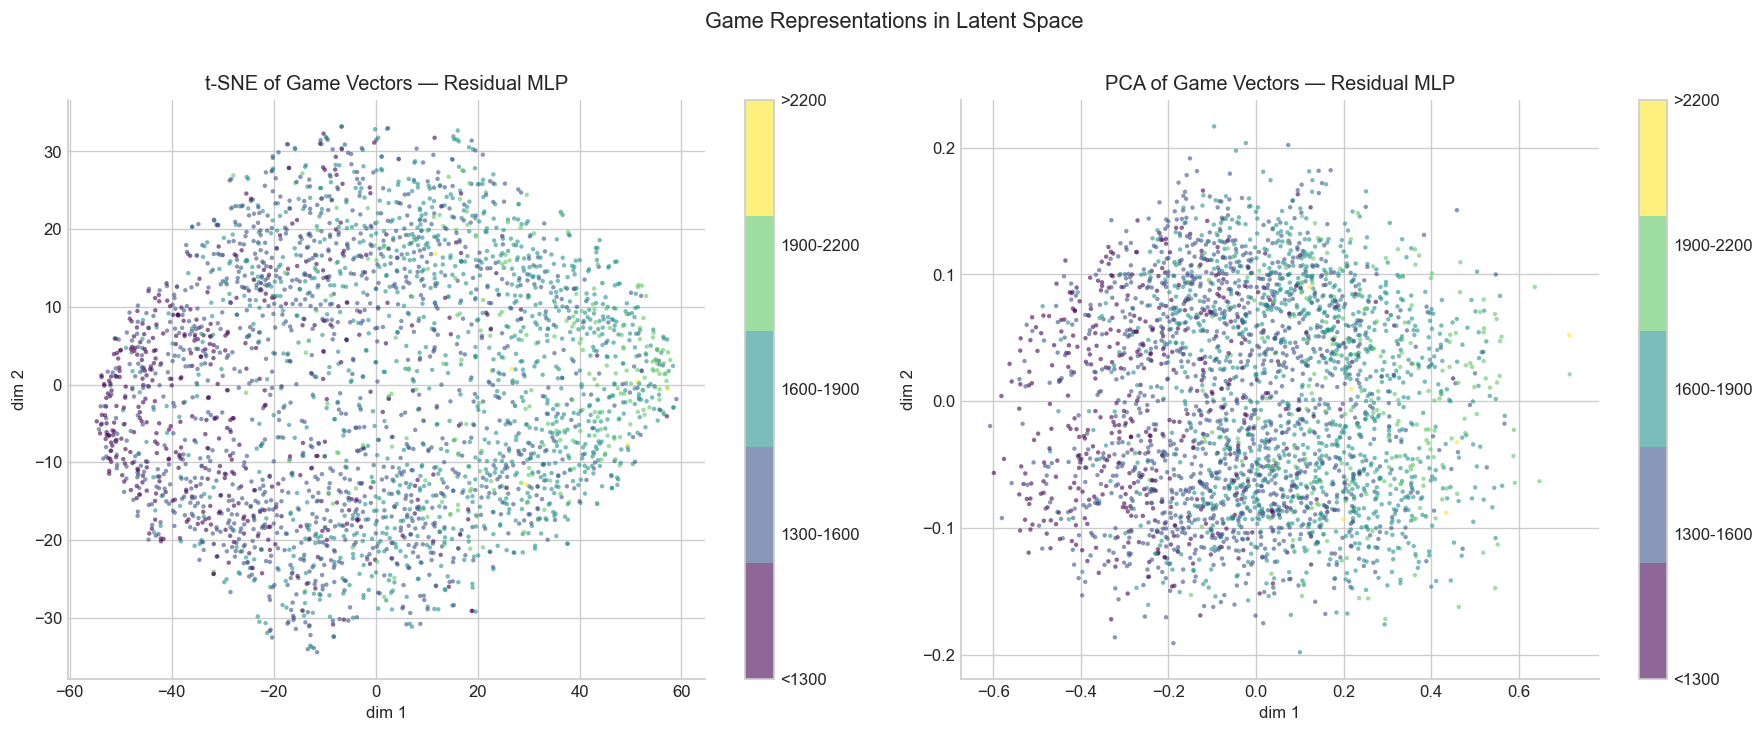

In [18]:
n_vis   = min(3000, len(test_ds))
vectors = []
elo_vis = []

model.eval()
with torch.no_grad():
    vis_loader = DataLoader(
        torch.utils.data.Subset(test_ds, range(n_vis)),
        batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_games)
    for batch in vis_loader:
        moves  = batch['moves'].to(device)
        clocks = batch['clocks'].to(device)
        turns  = batch['turns'].to(device)
        mask   = batch['mask'].to(device)
        static = batch['static'].to(device)
        vecs = model.game_embedding(moves, clocks, turns, mask, static)
        vectors.append(vecs.cpu().float().numpy())
        avg_elo_batch = ((batch['raw_elo'][:, 0] + batch['raw_elo'][:, 1]) / 2).numpy()
        elo_vis.extend(avg_elo_batch)

vectors = np.vstack(vectors)
elo_vis = np.array(elo_vis[:len(vectors)])
v_norm  = normalize(vectors, norm='l2')

bins_vis   = [0, 1300, 1600, 1900, 2200, 4000]
labels_vis = ['<1300', '1300-1600', '1600-1900', '1900-2200', '>2200']
bin_codes  = pd.cut(elo_vis, bins=bins_vis, labels=labels_vis).codes
cmap_d     = plt.cm.get_cmap('viridis', len(labels_vis))

print(f'Running t-SNE on {len(v_norm)} vectors...')
emb_tsne = TSNE(n_components=2, perplexity=min(40, len(v_norm)//4),
                random_state=RANDOM_STATE, max_iter=1000).fit_transform(v_norm)
emb_pca  = PCA(n_components=2).fit_transform(v_norm)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, emb, title in [(axes[0], emb_tsne, 't-SNE'), (axes[1], emb_pca, 'PCA')]:
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=bin_codes, cmap=cmap_d,
                    s=7, alpha=0.6, edgecolors='none')
    cbar = plt.colorbar(sc, ax=ax, ticks=range(len(labels_vis)))
    cbar.ax.set_yticklabels(labels_vis)
    ax.set_title(f'{title} of Game Vectors — Residual MLP')
    ax.set_xlabel('dim 1'); ax.set_ylabel('dim 2')
plt.suptitle('Game Representations in Latent Space', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## Feature Group Importance

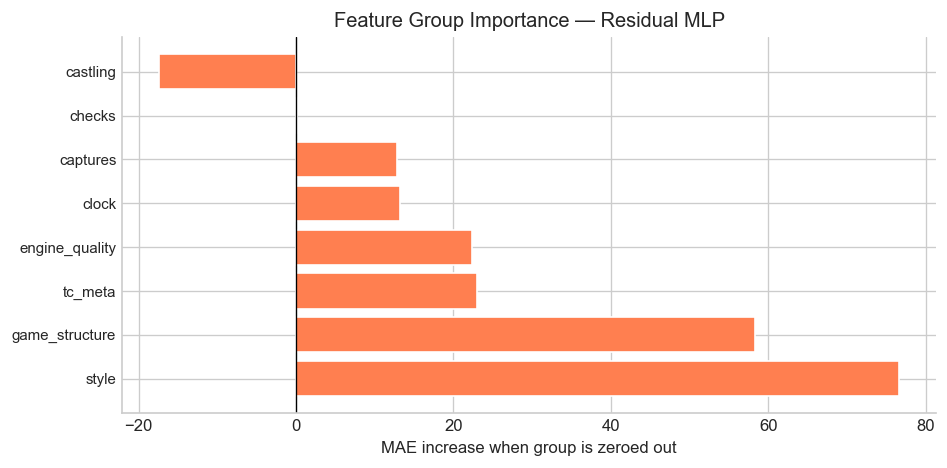

  style               Δ = +76.6
  game_structure      Δ = +58.3
  tc_meta             Δ = +23.0
  engine_quality      Δ = +22.3
  clock               Δ = +13.2
  captures            Δ = +12.8
  checks              Δ = +0.1
  castling            Δ = -17.4


In [19]:
model.eval()
test_batch = next(iter(test_loader))
moves_b  = test_batch['moves'].to(device)
clocks_b = test_batch['clocks'].to(device)
turns_b  = test_batch['turns'].to(device)
mask_b   = test_batch['mask'].to(device)
static_b = test_batch['static'].to(device)
raw_elos = test_batch['raw_elo']

with torch.no_grad():
    wp0, bp0, _ = model(moves_b, clocks_b, turns_b, mask_b, static_b)
wp0_e, bp0_e = preds_to_elo(wp0, bp0)
base_mae = (mean_absolute_error(raw_elos[:, 0].numpy(), wp0_e) +
            mean_absolute_error(raw_elos[:, 1].numpy(), bp0_e))

group_deltas = {}
for group_name, prefixes in GROUP_PREFIXES.items():
    if not FEATURE_GROUPS.get(group_name, False): continue
    col_idx = [i for i, c in enumerate(static_cols)
               if any(c.startswith(p) for p in prefixes)]
    if not col_idx: continue
    masked = static_b.clone()
    masked[:, col_idx] = 0.
    with torch.no_grad():
        wp_m, bp_m, _ = model(moves_b, clocks_b, turns_b, mask_b, masked)
    wm_e, bm_e = preds_to_elo(wp_m, bp_m)
    masked_mae = (mean_absolute_error(raw_elos[:, 0].numpy(), wm_e) +
                  mean_absolute_error(raw_elos[:, 1].numpy(), bm_e))
    group_deltas[group_name] = masked_mae - base_mae

if group_deltas:
    sorted_groups = sorted(group_deltas.items(), key=lambda x: -x[1])
    gnames, deltas = zip(*sorted_groups)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(range(len(gnames)), deltas, color='coral', edgecolor='white')
    ax.set_yticks(range(len(gnames)))
    ax.set_yticklabels(gnames, fontsize=9)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('MAE increase when group is zeroed out')
    ax.set_title('Feature Group Importance — Residual MLP')
    plt.tight_layout(); plt.show()
    for name, delta in sorted_groups:
        print(f'  {name:<18s}  Δ = {delta:+.1f}')

## Anomaly Detection

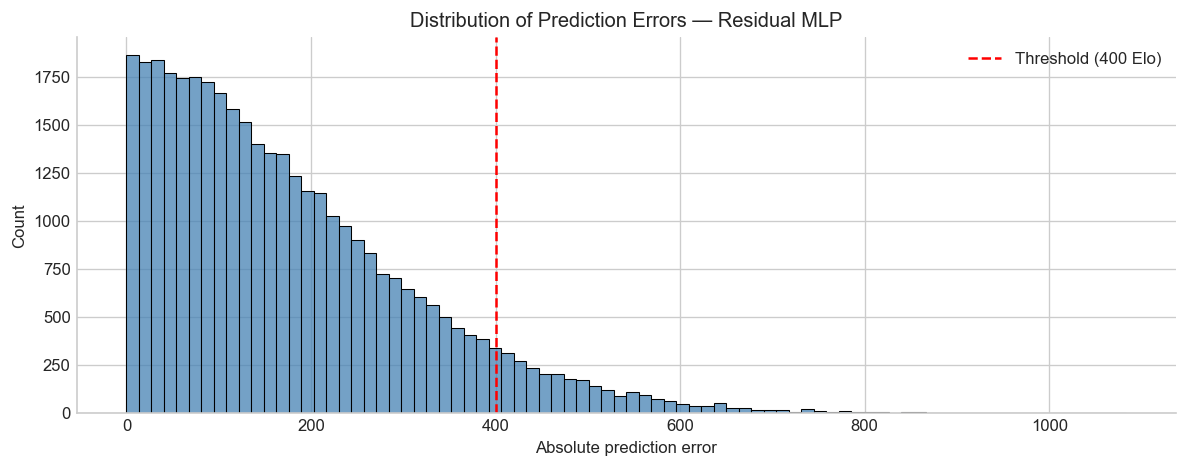

Flagged 2825 games with error > 400 Elo  (7.7%)


In [20]:
avg_pred  = (white_preds + black_preds) / 2
avg_true  = (white_trues + black_trues) / 2
diff      = avg_pred - avg_true
abs_diff  = np.abs(diff)
THRESHOLD = 400

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(abs_diff, bins=80, ax=ax, color='steelblue')
ax.axvline(THRESHOLD, color='red', ls='--', lw=1.5, label=f'Threshold ({THRESHOLD} Elo)')
ax.set_xlabel('Absolute prediction error')
ax.set_title('Distribution of Prediction Errors — Residual MLP')
ax.legend()
plt.tight_layout(); plt.show()

n_flagged = int(np.sum(abs_diff > THRESHOLD))
print(f'Flagged {n_flagged} games with error > {THRESHOLD} Elo  '
      f'({n_flagged / len(diff) * 100:.1f}%)')

## Single-Game Inference

Paste any PGN below and run the cell. Works with Lichess and chess.com exports.

  White Elo   predicted:  1848   actual: 1546
  Black Elo   predicted:  1763   actual: 1534


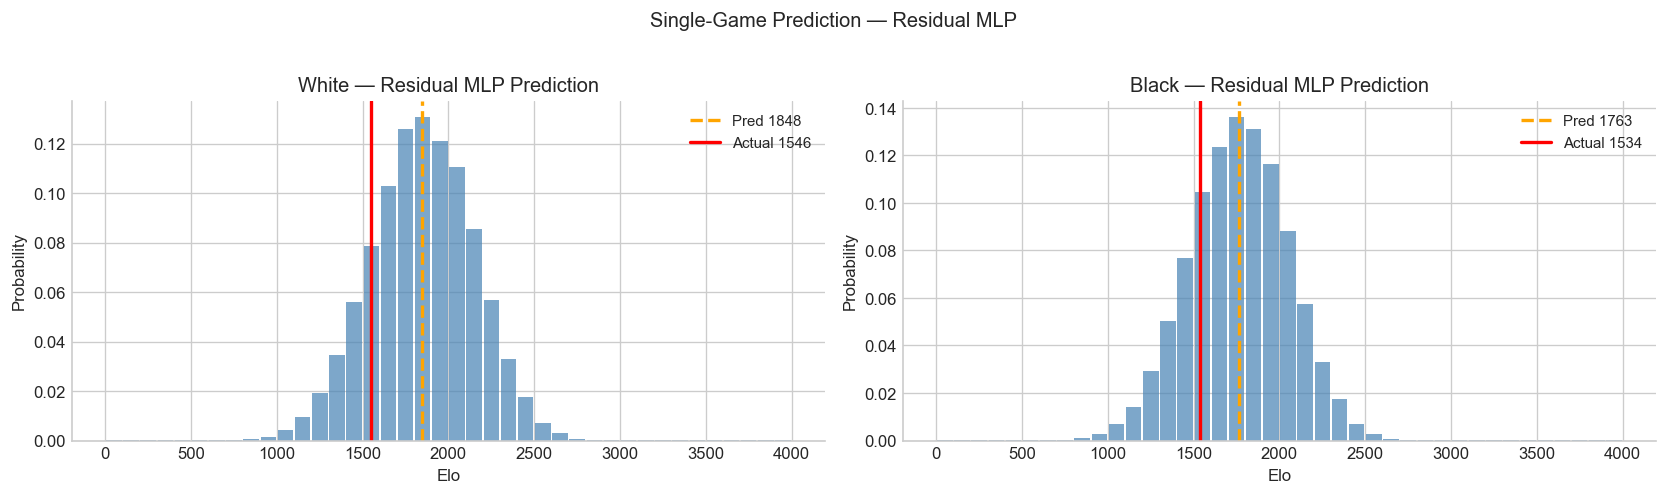

In [21]:
EXAMPLE_PGN = """
[Event "Live Chess"]
[Site "Chess.com"]
[Date "2026.06.03"]
[White "ThomasPinkerton"]
[Black "AliC0rn"]
[Result "1-0"]
[TimeControl "600"]
[WhiteElo "1546"]
[BlackElo "1534"]

1. e4 d5 2. exd5 Qxd5 3. Nc3 Qa5 4. d4 c6 5. Nf3 Nf6 6. Bc4 Bg4 7. O-O e6
8. Bd2 Qc7 9. h3 Bf5 10. Qe2 Bd6 11. a3 O-O 12. Bg5 Nbd7 13. Rfe1 h6
14. Bxf6 Nxf6 15. Ne5 Rfe8 16. Bd3 Bxd3 17. Qxd3 Nd5 18. Nxd5 cxd5
19. Re3 Rac8 20. c3 Bxe5 21. Rxe5 f6 22. Re3 Qb6 23. Re2 Qd6 24. Rae1 e5
25. dxe5 fxe5 26. Qg3 Qb6 27. Rxe5 Rxe5 28. Qxe5 Qxb2 29. Qe6+ Kh7
30. Qxc8 Qxa3 31. Qf5+ Kh8 32. Re8+ Qf8 33. Rxf8# 1-0
"""


# load AE encoder to compute the embedding for the inference game
ae_encoder_for_inference = None
if AE_MODEL_PATH.exists():
    ae_encoder_for_inference = build_encoder(vocab_size(), 64, 128, AE_LATENT_DIM).to(device)
    ae_encoder_for_inference.load_state_dict(
        torch.load(AE_MODEL_PATH, map_location=device, weights_only=False))
    ae_encoder_for_inference.eval()


def predict_pgn(pgn_str):
    import chess.pgn
    game = chess.pgn.read_game(io.StringIO(pgn_str))
    if game is None:
        raise ValueError('Could not parse PGN')
    headers   = dict(game.headers)
    moves_str = game.board().variation_san(list(game.mainline_moves()))
    result    = headers.get('Result', '*')

    board_f = cff.extract_features(moves_str, result)
    for side in ['castle_side_white', 'castle_side_black']:
        val = board_f.pop(side, 'none')
        for cat in ['king', 'queen', 'none']:
            board_f[f'{side}_{cat}'] = 1. if val == cat else 0.

    tc_base, tc_inc = 600, 0
    tc_str = headers.get('TimeControl', '600+0')
    m = re.match(r'(\d+)\+(\d+)', tc_str)
    if m:
        tc_base, tc_inc = int(m.group(1)), int(m.group(2))
    else:
        ms = re.match(r'^(\d+)$', tc_str)
        if ms: tc_base = int(ms.group(1))

    clock_f      = clock_features(pgn_str, tc_base)
    feature_dict = {**board_f, **clock_f, 'tc_base': tc_base, 'tc_inc': tc_inc}
    raw_static   = np.array([feature_dict.get(c, 0.) for c in static_cols], dtype=np.float32)
    scaled       = ((np.nan_to_num(raw_static, nan=0.) - scaler.mean_) / scaler.scale_).astype(np.float32)

    # AE embedding for the inference game
    if ae_encoder_for_inference is not None:
        moves_list = parse_moves(pgn_str)[0]
        ae_ids     = torch.tensor([encode_move(mv) for mv in moves_list[:AE_MAX_SEQ]],
                                   dtype=torch.long).unsqueeze(0).to(device)
        ae_mask    = (ae_ids != 0)
        with torch.no_grad():
            ae_vec = ae_encoder_for_inference(ae_ids, ae_mask).cpu().numpy().squeeze()
        combined = np.concatenate([scaled, ae_vec]).astype(np.float32)
    else:
        combined = np.concatenate([scaled, np.zeros(AE_LATENT_DIM, dtype=np.float32)])

    static_t = torch.tensor(combined, dtype=torch.float32).unsqueeze(0).to(device)
    dummy_m  = torch.zeros(1, 1, dtype=torch.long).to(device)
    dummy_c  = torch.zeros(1, 1).to(device)
    dummy_t  = torch.zeros(1, 1).to(device)
    dummy_mk = torch.ones(1, 1).to(device)

    model.eval()
    with torch.no_grad():
        white_out, black_out, _ = model(dummy_m, dummy_c, dummy_t, dummy_mk, static_t)

    white_dist = white_out.cpu().numpy().squeeze()
    black_dist = black_out.cpu().numpy().squeeze()
    return {'white_elo': dist_to_elo(white_dist), 'black_elo': dist_to_elo(black_dist),
            'white_dist': white_dist, 'black_dist': black_dist}


prediction = predict_pgn(EXAMPLE_PGN)

actual_white, actual_black = None, None
for line in EXAMPLE_PGN.split('\n'):
    if '[WhiteElo' in line:
        try: actual_white = int(re.search(r'"(\d+)"', line).group(1))
        except: pass
    if '[BlackElo' in line:
        try: actual_black = int(re.search(r'"(\d+)"', line).group(1))
        except: pass

print('=' * 45)
print(f'  White Elo   predicted: {prediction["white_elo"]:5.0f}'
      + (f'   actual: {actual_white}' if actual_white else ''))
print(f'  Black Elo   predicted: {prediction["black_elo"]:5.0f}'
      + (f'   actual: {actual_black}' if actual_black else ''))
print('=' * 45)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, dist, pred, actual, label in [
    (axes[0], prediction['white_dist'], prediction['white_elo'], actual_white, 'White'),
    (axes[1], prediction['black_dist'], prediction['black_elo'], actual_black, 'Black')]:
    ax.bar(BIN_CENTERS, dist, width=90, color='steelblue', alpha=0.7)
    ax.axvline(pred, color='orange', lw=2, ls='--', label=f'Pred {pred:.0f}')
    if actual: ax.axvline(actual, color='red', lw=2, label=f'Actual {actual}')
    ax.set_xlabel('Elo'); ax.set_ylabel('Probability')
    ax.set_title(f'{label} — Residual MLP Prediction')
    ax.legend(fontsize=9)
plt.suptitle('Single-Game Prediction — Residual MLP', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

## Export

In [ ]:
# import subprocess, datetime
# nb_path  = os.path.abspath('chess_elo_residual.ipynb')
# out_dir  = os.path.abspath('output_files')
# os.makedirs(out_dir, exist_ok=True)
# ts       = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
# out_html = os.path.join(out_dir, f'chess_elo_residual_{MAX_GAMES:.0e}_{ts}.html')
# subprocess.run(['jupyter', 'nbconvert', '--to', 'html', '--no-input',
#                 '--output', out_html, nb_path], check=True)
# print(f'Exported: {out_html}')

Exported: c:\CodeBases\AppML_FinalProject\root\workspace\elias_sandbox\output_files\chess_elo_residual_3e+06_20260607_162646.html
